# ⚖️ Facial Symmetry Analysis
This notebook analyzes overall facial harmony and balance by calculating bilateral feature deviations from the true facial midline.

In [49]:
import cv2
import math
import numpy as np
import mediapipe as mp
import urllib.request
import os
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import warnings
warnings.filterwarnings('ignore')

print(f"MediaPipe {mp.__version__} | OpenCV {cv2.__version__}")

# Download model if not exists
MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading Face Landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MODEL_PATH)

def extract_landmarks(image_path):
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"Could not read {image_path}")
    h, w, _ = img.shape
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1,
        min_face_detection_confidence=0.1,
        min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        res = detector.detect(mp_image)
        if not res.face_landmarks:
            raise ValueError("No face detected!")
        return res.face_landmarks[0], img, rgb, h, w


MediaPipe 0.10.35 | OpenCV 5.0.0


In [50]:
# Defined landmark pairs: Right vs Left
PAIRS = {
    "Outer Eyebrow": (70, 300),
    "Inner Eyebrow": (107, 336),
    "Outer Eye": (33, 263),
    "Inner Eye": (133, 362),
    "Cheekbone (Zygion)": (234, 454),
    "Nose Alar Base": (129, 358),
    "Mouth Corner": (61, 291),
    "Jaw Angle": (132, 361),  
    "Chin Corner": (150, 379) 
}

MIDLINE_TOP = 10   # Top of forehead
MIDLINE_MID = 9    # Nasion
MIDLINE_BOT = 152  # Chin Tip

def pt(lm, idx, w, h):
    return np.array([lm[idx].x * w, lm[idx].y * h])

def point_to_line_dist(p, p1, p2):
    # Shortest distance from point p to the line defined by p1 and p2
    return np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)

def analyze_symmetry(lm, w, h):
    # Establish midline vector using Nasion and Chin
    mid_pt = pt(lm, MIDLINE_MID, w, h)
    bot_pt = pt(lm, MIDLINE_BOT, w, h)
    
    line_vec = bot_pt - mid_pt
    line_len = np.linalg.norm(line_vec)
    
    # Extrapolate top and bottom for drawing the long arrow
    draw_top = mid_pt - (line_vec / line_len) * (h * 0.20)
    draw_bot = bot_pt + (line_vec / line_len) * (h * 0.05)
    
    scores = []
    points_to_draw = []
    
    for name, (r_idx, l_idx) in PAIRS.items():
        p_r = pt(lm, r_idx, w, h)
        p_l = pt(lm, l_idx, w, h)
        
        # Distance to midline
        d_r = point_to_line_dist(p_r, mid_pt, bot_pt)
        d_l = point_to_line_dist(p_l, mid_pt, bot_pt)
        
        # Width symmetry (0 to 1)
        if max(d_r, d_l) == 0:
            w_sym = 1.0
        else:
            w_sym = min(d_r, d_l) / max(d_r, d_l)
            
        # Vertical alignment symmetry
        lr_vec = p_l - p_r
        lr_len = np.linalg.norm(lr_vec)
        if lr_len > 0 and line_len > 0:
            cos_angle = np.abs(np.dot(lr_vec, line_vec)) / (lr_len * line_len)
            v_sym = max(0, 1.0 - cos_angle * 3) # Penalize tilt slightly more
        else:
            v_sym = 1.0
            
        pair_score = (w_sym * 0.7 + v_sym * 0.3) * 100
        scores.append(pair_score)
        
        points_to_draw.extend([p_r, p_l])
        
    overall_score = np.mean(scores)
    return overall_score, points_to_draw, draw_top, draw_bot


In [51]:
def draw_symmetry(img_rgb, points, draw_top, draw_bot, score):
    import cv2
    import numpy as np
    
    h, w = img_rgb.shape[:2]
    
    # Anti-Aliasing Fix: If image is too small, OpenCV rasterizes tiny circles into ugly diamonds.
    # We upscale the canvas to guarantee a minimum height of 1200px before drawing.
    target_h = max(h, 1200)
    upscale = target_h / h
    
    if upscale > 1.0:
        target_w = int(w * upscale)
        img = cv2.resize(img_rgb, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
    else:
        img = img_rgb.copy()
        
    scale = target_h / 800.0
    
    # Adjust midline points to upscaled canvas
    t_pt = (int(draw_top[0] * upscale), int(draw_top[1] * upscale))
    b_pt = (int(draw_bot[0] * upscale), int(draw_bot[1] * upscale))
    
    line_color = (255, 255, 255)
    line_thickness = max(1, int(1.5 * scale))
    cv2.arrowedLine(img, b_pt, t_pt, line_color, line_thickness, cv2.LINE_AA, tipLength=0.03)
    cv2.arrowedLine(img, t_pt, b_pt, line_color, line_thickness, cv2.LINE_AA, tipLength=0.03)
    
    # 2. Draw perfectly smooth hollow white circles
    r_white = max(4, int(3.5 * scale))
    t_white = max(1, int(1.2 * scale))
    
    for p in points:
        center = (int(p[0] * upscale), int(p[1] * upscale))
        # Draw the dark outline (+2 thickness for drop shadow effect)
        cv2.circle(img, center, r_white, (60, 60, 60), t_white + 2, cv2.LINE_AA)
        # Draw the white ring
        cv2.circle(img, center, r_white, (255, 255, 255), t_white, cv2.LINE_AA)
        
    return img


Please select the FRONTAL face photo in the popup window...
Processing: C:/Users/PratikJPatel/Downloads/360_F_276114144_xyAwCmx6IraojhvC2l9cNQEYAx6d28Nq.jpg

             ⚖️ FACIAL SYMMETRY REPORT

  Overall Score: 95.0 / 100
  Category:      Highly Symmetric

  Explanation:   Your facial symmetry is exceptional, with nearly perfect left-right balance. Such high symmetry is rare and indicates excellent harmonic proportions.



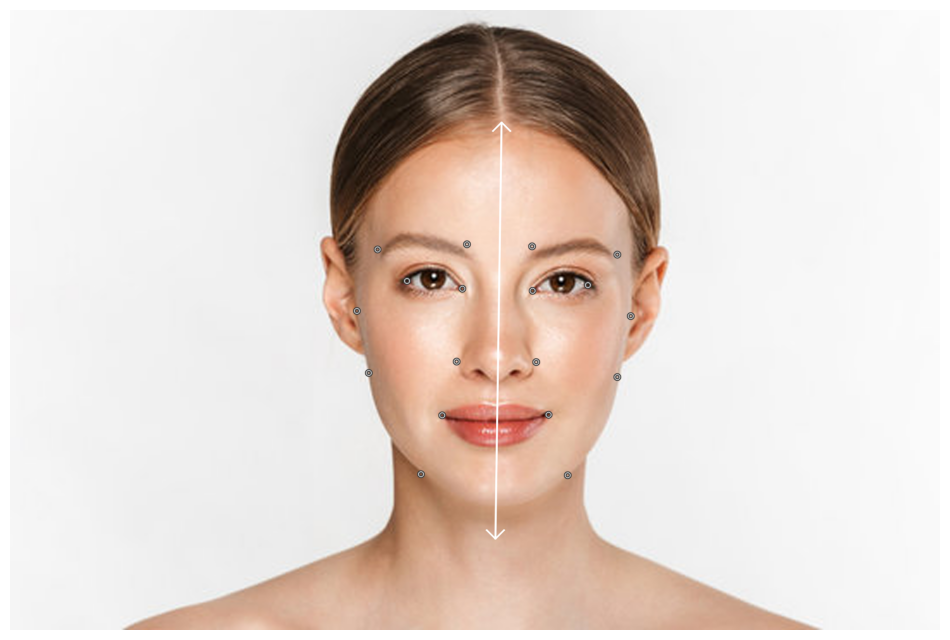

In [52]:
print('Please select the FRONTAL face photo in the popup window...')
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
IMAGE_PATH = filedialog.askopenfilename(title="Select Frontal Photo", filetypes=[('Image files', '*.jpg *.jpeg *.png')])
root.destroy()

if not IMAGE_PATH:
    raise ValueError("No image selected.")

print(f"Processing: {IMAGE_PATH}")

lm, bgr, rgb, h, w = extract_landmarks(IMAGE_PATH)
score, points, d_top, d_bot = analyze_symmetry(lm, w, h)

out_img = draw_symmetry(rgb, points, d_top, d_bot, score)

print("\n=========================================================")
print("             ⚖️ FACIAL SYMMETRY REPORT")
print("=========================================================\n")

if score >= 90:
    desc = "Highly Symmetric"
    expl = "Your facial symmetry is exceptional, with nearly perfect left-right balance. Such high symmetry is rare and indicates excellent harmonic proportions."
elif score >= 80:
    desc = "Very Symmetric"
    expl = "Your facial symmetry is notably above average, with balanced features and only minor natural deviations."
elif score >= 70:
    desc = "Quite Symmetric"
    expl = "Your face shows a normal, healthy level of symmetry. Some mild asymmetric variations are present, which are common in natural faces."
else:
    desc = "Asymmetric"
    expl = "Your face shows noticeable asymmetry between the left and right sides. This could be due to natural bone structure, muscular habits, or head pose."

print(f"  Overall Score: {score:.1f} / 100")
print(f"  Category:      {desc}\n")
print(f"  Explanation:   {expl}")
print("\n=========================================================")

plt.figure(figsize=(12, 12))
plt.imshow(out_img)
plt.axis("off")
plt.show()
